In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("project_1_data.csv")

In [3]:
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 52.3+ KB


In [6]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,6.070000e+02,607.000000,607.00000
mean,2021.405272,3.240001e+05,112297.869852,70.92257
std,0.692133,1.544357e+06,70957.259411,40.70913
min,2020.000000,4.000000e+03,2859.000000,0.00000
25%,2021.000000,7.000000e+04,62726.000000,50.00000
50%,2022.000000,1.150000e+05,101570.000000,100.00000
75%,2022.000000,1.650000e+05,150000.000000,100.00000
max,2022.000000,3.040000e+07,600000.000000,100.00000


In [7]:
df["is_us"] = df["employee_residence"] == "US"

df.groupby("is_us")["salary_in_usd"].mean()

is_us
False     67754.036364
True     149194.117470
Name: salary_in_usd, dtype: float64

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

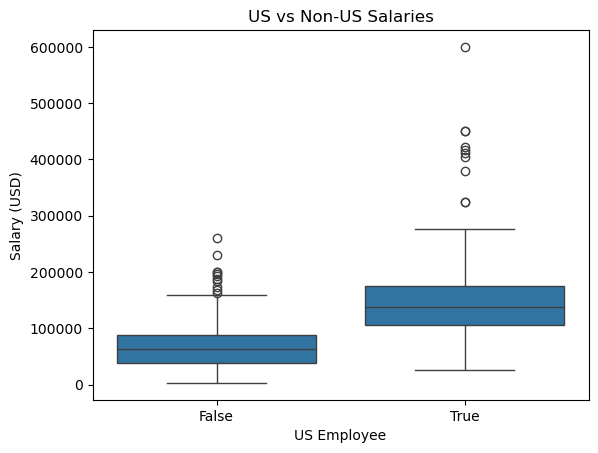

In [14]:
sns.boxplot(x="is_us", y="salary_in_usd", data=df)

plt.title("US vs Non-US Salaries")
plt.xlabel("US Employee")
plt.ylabel("Salary (USD)")
plt.savefig("us_vs_non_us.png", bbox_inches='tight')
plt.show()

In [11]:
df.groupby("experience_level")["salary_in_usd"].mean().sort_values()

experience_level
EN     61643.318182
MI     87996.056338
SE    138617.292857
EX    199392.038462
Name: salary_in_usd, dtype: float64

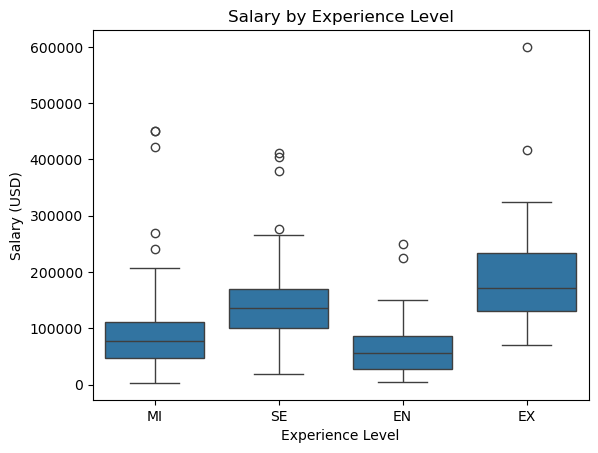

In [15]:
sns.boxplot(x="experience_level", y="salary_in_usd", data=df)

plt.title("Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")
plt.savefig("experience_salary.png", bbox_inches='tight')
plt.show()

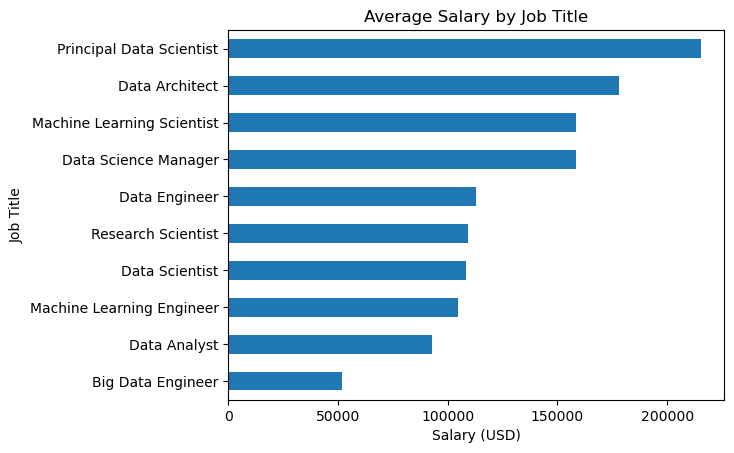

In [16]:
top_jobs = df["job_title"].value_counts().head(10).index

df_top = df[df["job_title"].isin(top_jobs)]

df_top.groupby("job_title")["salary_in_usd"].mean().sort_values().plot(kind="barh")

plt.title("Average Salary by Job Title")
plt.xlabel("Salary (USD)")
plt.ylabel("Job Title")
plt.savefig("job_title_salary.png", bbox_inches='tight')
plt.show()